# Split-Plot Designs

## Overview
Split-plot designs arise when one factor is applied to large experimental units (whole plots) and a second factor is applied to sub-units within each whole plot. They produce a **partly nested** structure with two distinct error terms.

**Classic ecology example:** disturbance treatment applied to whole plots; species addition applied to subplots within each plot. The whole-plot error (variation among plots within disturbance treatments) is separate from the subplot error.

**Why two error terms?**
Whole-plot treatments are replicated at the whole-plot level — the error for testing them is whole-plot variation. Subplot treatments and interactions are tested against the subplot error.

**Quinn & Keough (2002) ch. 11.**

---

In [1]:
library(tidyverse); library(lme4); library(lmerTest); library(emmeans)
set.seed(88)
# Intertidal experiment:
#   Whole-plot factor (between plots):  Disturbance (None / Scrape)
#   Subplot factor (within plots):      Nutrient addition (Control / +N / +P)
#   Design: 6 whole plots per disturbance; 3 subplots per plot
n_plots <- 6; n_sub <- 3; n_dist <- 2
disturbance <- c("None","Scrape")
nutrients   <- c("Control","+N","+P")

dat <- expand.grid(
  plot_id    = 1:(n_plots*n_dist),
  nutrient   = factor(nutrients)
)
dat$disturbance <- factor(rep(rep(disturbance, each=n_plots), each=n_sub))
# Plot random effect (whole-plot error)
plot_re <- rep(rnorm(n_plots*n_dist, 0, 3), each=n_sub)
# Fixed effects: disturbance reduces biomass; +N increases it; interaction
dist_eff <- ifelse(dat$disturbance=="Scrape", -6, 0)
nutr_eff <- ifelse(dat$nutrient=="+N", 5, ifelse(dat$nutrient=="+P", 2, 0))
int_eff  <- ifelse(dat$disturbance=="Scrape" & dat$nutrient=="+N", -3, 0)
dat$biomass <- 20 + dist_eff + nutr_eff + int_eff + plot_re + rnorm(nrow(dat),0,2)
cat("Split-plot dataset — design structure:\n")
cat("  Whole-plot factor: Disturbance (2 levels, 6 plots each)\n")
cat("  Subplot factor:    Nutrient (3 levels, tested within plots)\n")
print(table(dat$disturbance, dat$nutrient))

Warning message:
"package 'tidyverse' was built under R version 4.4.3"
Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Warning message:
"package 'purrr' was built under R version 4.4.3"
Warning message:
"package 'dplyr' was built under R version 4.4.3"
Warning message:
"package 'stringr' was built under R version 4.4.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'lme4' was built under R version 4.4.3"
Loading required package: Matrix


Attaching package: 'Matrix'


Th

Split-plot dataset — design structure:
  Whole-plot factor: Disturbance (2 levels, 6 plots each)
  Subplot factor:    Nutrient (3 levels, tested within plots)
        
         +N +P Control
  None    6  0      12
  Scrape  6 12       0


---
## Fitting split-plot with LMM (correct approach)

In [2]:
# The correct split-plot analysis uses LMM with plot as a random effect
# plot_id is the whole-plot unit — its random effect IS the whole-plot error
m_split <- lmer(biomass ~ disturbance * nutrient + (1|plot_id), data=dat)
cat("Split-plot LMM summary:\n")
print(anova(m_split))  # lmerTest gives p-values

cat("\nRandom effects (whole-plot variance component):\n")
print(VarCorr(m_split))

cat("\nInterpretation of F-ratios:\n")
cat("  Disturbance tested against whole-plot variance (plot_id random effect)\n")
cat("  Nutrient and interaction tested against subplot residual variance\n")

fixed-effect model matrix is rank deficient so dropping 2 columns / coefficients

boundary (singular) fit: see help('isSingular')



Split-plot LMM summary:


Missing cells for: disturbanceNone:nutrient+P, disturbanceScrape:nutrientControl.  
Interpret type III hypotheses with care.



Type III Analysis of Variance Table with Satterthwaite's method
                     Sum Sq Mean Sq NumDF DenDF F value    Pr(>F)    
disturbance          425.99  425.99     1    32 20.0482 9.006e-05 ***
nutrient             111.78   55.89     2    32  2.6304   0.08757 .  
disturbance:nutrient                                                 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Random effects (whole-plot variance component):
 Groups   Name        Std.Dev.
 plot_id  (Intercept) 0.0000  
 Residual             4.6096  

Interpretation of F-ratios:
  Disturbance tested against whole-plot variance (plot_id random effect)
  Nutrient and interaction tested against subplot residual variance


Estimated means:
 disturbance nutrient emmean   SE df lower.CL upper.CL
 None        +N         24.8 1.94 32    20.85     28.8
 Scrape      +N         12.9 1.94 32     8.94     16.8
 None        +P       nonEst   NA NA       NA       NA
 Scrape      +P         16.2 1.33 32    13.49     18.9
 None        Control    20.7 1.33 32    17.97     23.4
 Scrape      Control  nonEst   NA NA       NA       NA

Degrees-of-freedom method: kenward-roger 
Confidence level used: 0.95 

Simple effects: nutrient within each disturbance level:
disturbance = None:
 nutrient emmean   SE df lower.CL upper.CL
 +N         24.8 1.94 32    20.85     28.8
 +P       nonEst   NA NA       NA       NA
 Control    20.7 1.33 32    17.97     23.4

disturbance = Scrape:
 nutrient emmean   SE df lower.CL upper.CL
 +N         12.9 1.94 32     8.94     16.8
 +P         16.2 1.33 32    13.49     18.9
 Control  nonEst   NA NA       NA       NA

Degrees-of-freedom method: kenward-roger 
Confidence level used: 0.95 
disturbanc

Warning message:
"Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`)."
Warning message:
"Removed 1 row containing missing values or values outside the scale range
(`geom_line()`)."


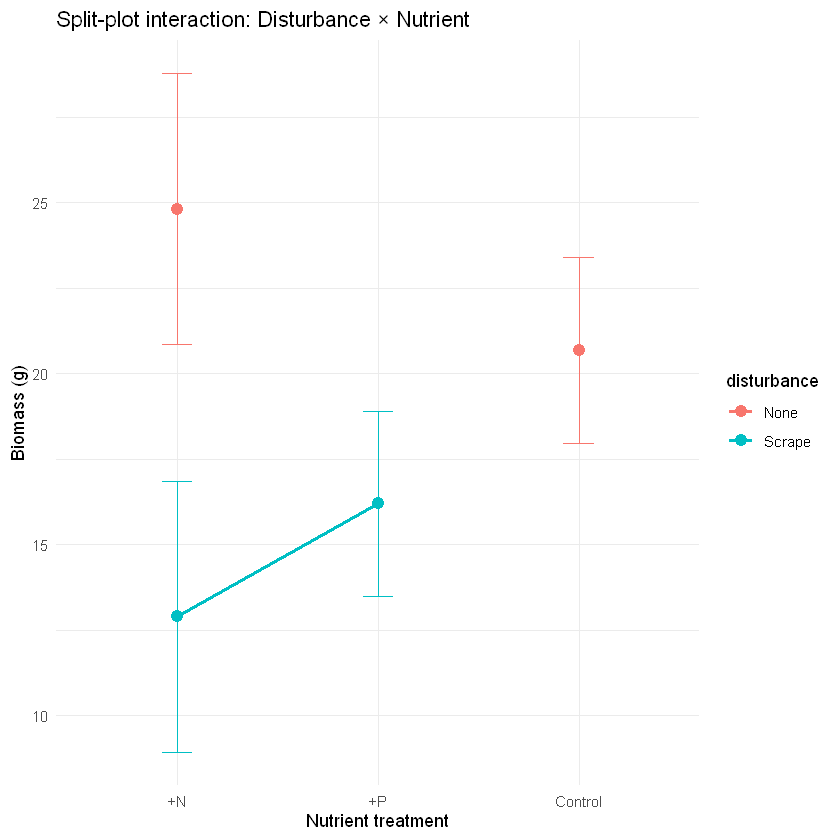

In [3]:
# Estimated marginal means and interaction
em <- emmeans(m_split, ~ disturbance * nutrient)
cat("Estimated means:\n"); print(em)
cat("\nSimple effects: nutrient within each disturbance level:\n")
print(emmeans(m_split, ~ nutrient | disturbance))
print(pairs(emmeans(m_split, ~ nutrient | disturbance), adjust="tukey"))

# Interaction plot
ggplot(as.data.frame(summary(em)),
       aes(nutrient, emmean, colour=disturbance, group=disturbance)) +
  geom_point(size=3) + geom_line(linewidth=1) +
  geom_errorbar(aes(ymin=lower.CL, ymax=upper.CL), width=0.15) +
  labs(title="Split-plot interaction: Disturbance × Nutrient",
       y="Biomass (g)", x="Nutrient treatment") +
  theme_minimal()

In [4]:
# Comparison: wrong analysis (ignoring whole-plot structure)
m_wrong <- lm(biomass ~ disturbance * nutrient, data=dat)
cat("WRONG — ignoring whole-plot error (pseudoreplication):\n")
print(anova(m_wrong))
cat("\nCORRECT — split-plot LMM:\n")
print(anova(m_split))
cat("\nThe wrong analysis over-estimates df for Disturbance,\n")
cat("giving an anti-conservative test for the whole-plot factor.\n")

WRONG — ignoring whole-plot error (pseudoreplication):
Analysis of Variance Table

Response: biomass
            Df Sum Sq Mean Sq F value    Pr(>F)    
disturbance  1 436.26  436.26 20.5314 7.719e-05 ***
nutrient     2 111.78   55.89  2.6304   0.08757 .  
Residuals   32 679.95   21.25                      
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

CORRECT — split-plot LMM:


Missing cells for: disturbanceNone:nutrient+P, disturbanceScrape:nutrientControl.  
Interpret type III hypotheses with care.



Type III Analysis of Variance Table with Satterthwaite's method
                     Sum Sq Mean Sq NumDF DenDF F value    Pr(>F)    
disturbance          425.99  425.99     1    32 20.0482 9.006e-05 ***
nutrient             111.78   55.89     2    32  2.6304   0.08757 .  
disturbance:nutrient                                                 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

The wrong analysis over-estimates df for Disturbance,
giving an anti-conservative test for the whole-plot factor.


---
## Common Pitfalls

**1. Testing the whole-plot factor against the subplot error**
This is pseudoreplication (Hurlbert 1984). The whole-plot factor (e.g., disturbance applied to entire plots) is only replicated at the whole-plot level. Testing it against within-plot (subplot) variance uses far too many degrees of freedom and produces anti-conservative F-ratios.

**2. Confusing which factor is whole-plot vs subplot**
The whole-plot factor is the one applied to the larger unit — the one that determines which plots are independent replicates. Subplot factors are nested within whole plots. Getting this wrong reverses the error term assignment.

**3. Using standard two-way ANOVA instead of split-plot**
`lm(y ~ A * B)` treats all observations as independent. In a split-plot, subplots within the same whole plot are correlated. The correct analysis requires the whole-plot random effect (or the classical split-plot ANOVA with two error strata).

**4. Not checking that whole-plot replication is adequate**
The whole-plot factor is tested with fewer degrees of freedom (number of whole plots minus number of whole-plot treatment levels). A split-plot experiment with only 2–3 whole plots per treatment level has very low power for the whole-plot test, regardless of how many subplots are measured.

**5. Interpreting a significant interaction when whole-plot F is non-significant**
An interaction between a whole-plot and subplot factor is tested at the subplot level. A significant interaction does not salvage a non-significant whole-plot main effect — the two tests are independent.

**6. Forgetting to account for the split-plot structure in power calculations**
Power for the whole-plot factor depends on the number of whole plots (not subplots). Adding more subplots increases power for subplot and interaction tests but not for the whole-plot test.


---
*r_methods_library - Samantha McGarrigle*